# GROMACS simulation of the lamin A Ig-fold and respective mutations

The lamin A Ig-fold will be analyzed with GROMACS molecular dynamics simulations. Of special interest are the cysteine C522, and mutations R482Q and R545H.

A tutorial followed for basic GROMACS is: https://pubs.acs.org/doi/10.1021/acs.jpcb.4c04901

In [ ]:
# list the modules
module avail

# activate the modules
module load gromacs/2025.2

# change Ig-fold directory
cd "2025_09 Ig-fold"

   cd "2026_03 Ig-fold-M-high-mobility"
   cd "2026_03 Ig-fold-N-low-mobility"

#https://mmb.irbbarcelona.org/biobb/workflows
# generate a topology, choose CHARMMS and 1) water model
# ! echo 13 | ...
gmx pdb2gmx -f "data/1IFR_A.pdb" -o "gro/1IFR_A.gro" # -ignh -missing

   gmx pdb2gmx -f "data/9J8M_H_O1P.pdb" -o "gro/9J8M_H.gro" -ter
   gmx pdb2gmx -f "data/9J8N_R_O1P.pdb" -o "gro/9J8N_R.gro" -ter

# define unit cell and shape
gmx editconf -f "gro/1IFR_A.gro" -o "box/box_1IFR_A.gro" -c -d 1.2 -bt dodecahedron

   gmx editconf -f "gro/9J8M_R.gro" -o "box/box_9J8M_R.gro" -c -d 1.2 -bt dodecahedron
   gmx editconf -f "gro/9J8N_R.gro" -o "box/box_9J8N_R.gro" -c -d 1.2 -bt dodecahedron


# add solvent
gmx solvate -cp "box/box_1IFR_A.gro" -cs spc216.gro -o "solv/solv_1IFR_A.gro" -p "top/topol_1IFR_A.top"

   gmx solvate -cp "box/box_9J8M_R.gro" -cs spc216.gro -o "solv/solv_9J8M_R.gro" -p "top/9J8M_R/topol.top"
   gmx solvate -cp "box/box_9J8N_R.gro" -cs spc216.gro -o "solv/solv_9J8N_R.gro" -p "top/9J8N_R/topol.top"

# add ions
# ions.mdp as empty file
gmx grompp -f ions.mdp -c "solv/solv_1IFR_A.gro" -p "top/topol_1IFR_A.top" -o "ions/ions_1IFR_A.tpr" # -maxwarn 1

    gmx grompp -f ions.mdp -c "solv/solv_9J8M_R.gro" -p "top/9J8M_R/topol.top" -o "ions/ions_9J8M_R.tpr" -maxwarn 2
    gmx grompp -f ions.mdp -c "solv/solv_9J8N_R.gro" -p "top/9J8N_R/topol.top" -o "ions/ions_9J8N_R.tpr"

# neutralize and add salt
gmx genion -s "ions/ions_1IFR_A.tpr" -o "solv/solv_ions_1IFR_A.gro" -p "top/topol_1IFR_A.top" -pname K -nname CL -conc 0.1 -neutral
# visual check: open in PyMol and have an optional look here

    gmx genion -s "ions/ions_9J8M_R.tpr" -o "solv/solv_ions_9J8M_R.gro" -p "top/9J8M_R/topol.top" -pname K -nname CL -conc 0.1 -neutral
    gmx genion -s "ions/ions_9J8N_R.tpr" -o "solv/solv_ions_9J8N_R.gro" -p "top/9J8N_R/topol.top" -pname K -nname CL -conc 0.1 -neutral

# rewrap unit cell
# gmx grompp -f ions.mdp -c "solv/solv_ions_1IFR_A.gro" -p "top/topol_1IFR_A.top" -o "wrap/wrap_1IFR_A.tpr" #-maxwarn 1

# rewrap unit cell to .gro
# gmx trjconv -s "wrap/wrap_1IFR_A.tpr" -f "solv/solv_ions_1IFR_A.gro" -o "wrap/rewrap_1IFR_A.gro" -pbc mol -ur compact
# visual check: open in PyMol and have an optional look here

gmx trjconv -s raven_md_7Z21_R.tpr -f raven_md_7Z21_R.gro -n index.ndx -o Ig-R.gro -center -pbc mol -ur compact
# add all your input files before you continue

## Energy minimization

In [ ]:
# change to protein-wise directory
cd 1IFG_A

   cd "2026_03 Ig-fold-M-high-mobility/9J8M_R"
   cd "2026_03 Ig-fold-N-low-mobility/9J8N_R"

# prepare the energy minimization (em) input file
gmx grompp -f "../minim.mdp" -c "../solv/solv_ions_1IFR_A.gro" -p "../top/topol_1IFR_A.top" -o "em_1IFR_A.tpr"

   gmx grompp -f "../minim.mdp" -c "../solv/solv_ions_9J8M_H.gro" -p "../top/9J8M_H/topol.top" -o "em_9J8M_H.tpr"
   gmx grompp -f "../minim.mdp" -c "../solv/solv_ions_9J8N_H.gro" -p "../top/9J8N_H/topol.top" -o "em_9J8N_H.tpr"

# run minimization
# gmx mdrun -s "em_1IFR_A.tpr" -deffnm em

################
# BETTER       #
################
# export OMP_NUM_THREADS=1
# gmx mdrun -s "em_1IFR_A.tpr" -deffnm em -ntomp 1    # took ~15 min.
mpirun gmx_mpi mdrun -s "em_7Z21_H.tpr" -deffnm "em_7Z21_H" -ntomp 12

   mpirun gmx_mpi mdrun -s "em_9J8M_R2.tpr" -deffnm "em_9J8M_R2" -ntomp 12

# plot the energy curve
gmx energy -f em.edr -o "potential_em_1IFR_A.xvg" 

    gmx energy -f em_9J8M_R.edr -o "potential_em_9J8M_R.xvg" 

# now use the "Appendix: Plotting modality" below with

## Equilibration

In [ ]:
# open GPU instance
# load module gromacs again
cd "2025_09 Ig-fold/IFR_A"

# take care of the .itp and .top file (bottom of .top file)
# see in ../top folder :)

# NVT trajectory preparation
gmx grompp -f "../nvt.mdp" -c "em/em.gro" -r "em/em.gro" -p "../top/topol_1IFR_A.top" -o "nvt_1IFR_A.tpr"

    gmx grompp -f "../nvt.mdp" -c "em/em_9J8M_R2.gro" -r "em/em_9J8M_R2.gro" -p "../top/9J8M_R2/topol.top" -o "nvt_9J8M_R2.tpr"

# run NVT 
# RUNS FOR 100 ps
mpirun gmx_mpi mdrun -s "nvt_7Z21_H.tpr" -deffnm "nvt_7Z21_H" -ntomp 12
gmx energy -f nvt.edr -o "temperature_nvt_7Z21_H.xvg" 

    mpirun gmx_mpi mdrun -s "nvt_9J8M_R2.tpr" -deffnm "nvt_9J8M_R2" -ntomp 12       # 13:09 
    gmx energy -f "nvt_9J8M_R.edr" -o "temperature_nvt_9J8M_R.xvg"


# NPT trajectory preparation
gmx grompp -f "../npt.mdp" -c "nvt_7Z21_H.gro" -r "nvt_7Z21_H.gro" -p "../top/topol.top" -o "npt_7Z21_H.tpr"

    gmx grompp -f "../npt.mdp" -c "nvt/nvt_9J8M_R.gro" -r "nvt/nvt_9J8M_R.gro" -p "../top/9J8M_R/topol.top" -o "npt_9J8M_R.tpr" 

# run NPT
# RUNS FOR 500 ps
mpirun gmx_mpi mdrun -s "npt_7Z21_H.tpr" -deffnm "npt_7Z21_H" -ntomp 12
gmx energy -f npt.edr -o "pressure_npt_7Z21_H.xvg" 

   mpirun gmx_mpi mdrun -s "npt_9J8M_R.tpr" -deffnm "npt_9J8M_R" -ntomp 12     #
   gmx energy -f "npt_9J8M_R.edr" -o "pressure_npt_9J8M_R.xvg"

    # continue the run
   mpirun gmx_mpi mdrun -s "npt_9J8M_R.tpr" -deffnm "npt_9J8M_R" -cpi "npt_9J8M_R.cpt" -ntomp 12

# Production run

In [ ]:
#gmx grompp -f "../md.mdp" -c "npt_7Z21_H.gro" -p "../top/topol.top" -t "npt_7Z21_H.cpt" -o "test_md_7Z21_H.tpr"
gmx grompp -f "../md.mdp" -c "npt/npt_7Z21_H.gro" -p "../top/topol.top" -t "npt/npt_7Z21_H.cpt" -o "raven_md_7Z21_H.tpr"

    gmx grompp -f "../md.mdp" -c "npt/npt_9J8M_R.gro" -p "../top/9J8M_R/topol.top" -t "npt/npt_9J8M_R.cpt" -o "raven_md_9J8M_R.tpr"

# run a short test in command line
# srun gmx_mpi mdrun -deffnm "test_md_7Z21_H" 
mpirun gmx_mpi mdrun -deffnm "test_md_7Z21_H" -ntomp 12  #-maxh 24 #-pin on

    mpirun gmx_mpi mdrun -deffnm "test_md_9J8M_R" -ntomp 12  #-maxh 24 #-pin on

# periodic boundary conditions

# read out parameters
gmx dump -s "7Z21_H/raven_md_7Z21_H.tpr" | grep -E 'nsteps|dt'

In [ ]:
sbatch production_run.sh
squeue --me

In [ ]:
# neu starten
# srun gmx_mpi mdrun -s"xxx.tpr" -v -deffnm "robin_md_7Z21_H" -cpi "robin_7Z21_H.cpt" -maxh 1 -append -pin on

In [ ]:
# new start 
cd "2025_09 Ig-fold/7Z21_H"
sbatch raven_cont_8_12_7Z21_H.sh
squeue --me

In [ ]:
# rewrap the .gro
gmx trjconv -s raven_md_7Z21_H.tpr -f raven_md_7Z21_H.gro -o Ig_H.gro -pbc whole -ur compact
gmx trjconv -s raven_md_7Z21_H.tpr -f Ig_H.gro -o Ig_H_noPBC.gro -pbc mol -center
gmx trjconv -s raven_md_7Z21_H.tpr -f raven_md_7Z21_H.gro -o Ig_H.gro -pbc nojump

## Replicas

* Start from the same NVT and NPT runs.
* Make a new directory e.g. _7Z21_H_2_ and _7Z21_H_3_
* Generate the topology file there.
* A random seed is generated by GROMACS on default to start with different velocities.


In [1]:
# for H
cd "2025_09 Ig-fold/7Z21_H_2"
gmx grompp -f "../md.mdp" -c "../7Z21_H/npt/npt_7Z21_H.gro" -p "../top/topol.top" -t "../7Z21_H/npt/npt_7Z21_H.cpt" -o "raven_md_7Z21_H2.tpr"

# gmx grompp -f "../md.mdp" -c "../7Z21_H/npt/npt_7Z21_H.gro" -p "../top/topol.top" -t "../7Z21_H/npt/npt_7Z21_H.cpt" -o "raven_MD_7Z21_H_3.tpr"

# for Q
gmx grompp -f "../md.mdp" -c "npt/npt_7Z21_Q2.gro" -p "topol.top" -t "npt/npt_7Z21_Q2.cpt" -o "raven_md_7Z21_Q2.tpr"

# for R
gmx grompp -f "../md.mdp" -c "npt/npt_7Z21_R2.gro" -p "topol.top" -t "npt/npt_7Z21_R2.cpt" -o "raven_md_7Z21_R2.tpr"


# to continue in .sh file:
module purge
module load gromacs/2025.2

export OMP_NUM_THREADS=${SLURM_CPUS_PER_TASK}

srun --cpu-bind=none gmx_mpi mdrun -s "raven_md_7Z21_Q2.tpr" -deffnm "raven_md_7Z21_Q2" -cpi "raven_md_7Z21_Q2.cpt" -maxh 22 -pin on

# to continue on command line
cd "2025_09 Ig-fold/7Z21_H2"
sbatch raven_cont_8_12_7Z21_H.sh

SyntaxError: invalid syntax (858709679.py, line 1)

In [ ]:
# avoid jumping
# gmx trjconv -f test_md_7Z21_Q.xtc -o test_md_7Z21_Q_cluster.xtc -s test_md_7Z21_Q.tpr -pbc nojump
gmx trjconv -s raven_md_7Z21_Q.tpr -f raven_md_7Z21_Q.xtc -pbc mol -center

gmx rms -s raven_md_7Z21_Q.tpr -f raven_md_7Z21_Q.xtc -o rmsd_Q.xvg -tu ns -fit rot+trans

gmx rmsf -s raven_md_7Z21_Q.tpr -f raven_md_7Z21_Q.xtc -o rmsf_Q.xvg -res -fit yes

Velocity generation:

https://manual.gromacs.org/archive/4.6.5/online/mdp_opt.html#vel

**gen-vel:**

    no
        Do not generate velocities. The velocities are set to zero when there are no velocities in the input structure file.
    yes
        Generate velocities in grompp according to a Maxwell distribution at temperature gen-temp [K], with random seed gen-seed. This is only meaningful with integrator md. 

gen-temp: (300) [K]
    temperature for Maxwell distribution
gen-seed: (173529) [integer]
    used to initialize random generator for random velocities, when gen-seed is set to -1, the seed is calculated from the process ID number. 

## Appendix: Plotting modality

### Energy minimization

In [2]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

os.chdir("../2026_03 Ig-fold-M-high-mobility")

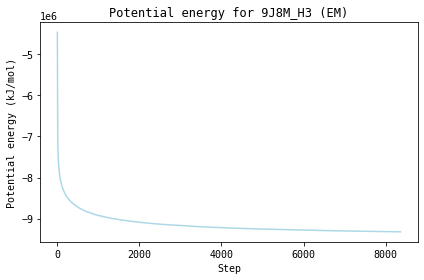

In [9]:
protein = "9J8M_H3"
file = "9J8M_H3/potential_em_9J8M_H3.xvg"

calculation = "EM"
value = "Potential energy"
unit = "(kJ/mol)"

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x,y, color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Step")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

In [4]:
os.getcwd()

'/raven/u/awaldherr/2025_09 Ig-fold'

### NVT run

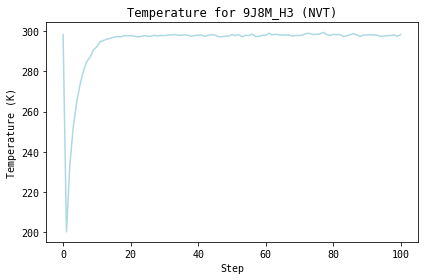

In [18]:
protein = "9J8M_H3"
file = "9J8M_H3/temperature_nvt_9J8M_H3.xvg"

os.chdir("../2026_03 Ig-fold-M-high-mobility")

calculation = "NVT"
value = "Temperature"
unit = "(K)"

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x,y, color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Step")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

### NPT run

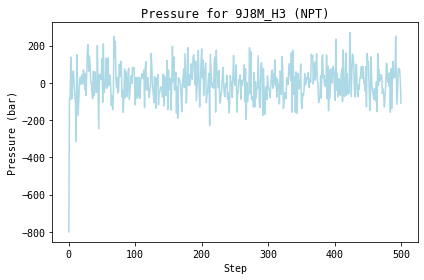

In [10]:
protein = "9J8M_H3"
file = "9J8M_H/pressure_npt_9J8M_H3.xvg"

calculation = "NPT"
value = "Pressure"
unit = "(bar)"

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x,y, color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Step")
#plt.ylim(-500, 500)
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

In [ ]:
# mdanalysis
# gromacs

# Production analysis

In [ ]:
# for the backbone rmsd

# 

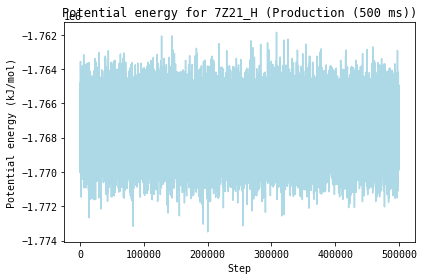

In [22]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_H"
file = "7Z21_H/potential_prod_7Z21_H.xvg"

calculation = "Production (500 ms)"
value = "Potential energy"
unit = "(kJ/mol)"

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x,y, color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Step")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

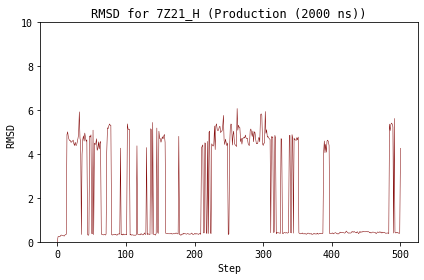

In [1]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_H"
file = "7Z21_H/rmsd_H.xvg"

calculation = "Production (2000 ns)"
value = "RMSD"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x[::100],y[::100], color="maroon", linestyle='-', linewidth=0.5)
plt.title(title)
plt.ylim(0, 10)
plt.xlabel("Step")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

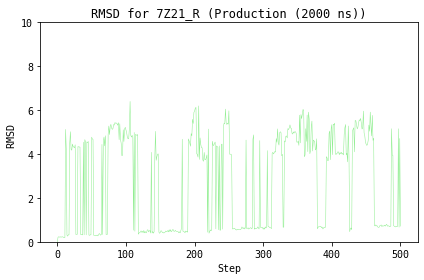

In [4]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_R"
file = "7Z21_R/rmsd_R.xvg"

calculation = "Production (2000 ns)"
value = "RMSD"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x[::100],y[::100], color="lightgreen", linestyle='-', linewidth=0.5)
plt.title(title)
plt.ylim(0, 10)
plt.xlabel("Step")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

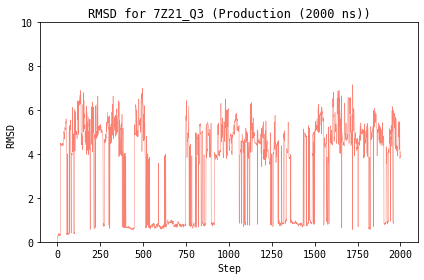

In [13]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_Q3"
file = "7Z21_Q3/rmsd_Q3.xvg"

calculation = "Production (2000 ns)"
value = "RMSD"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.plot(x[::100],y[::100], color="salmon", linestyle='-', linewidth=0.5)
plt.title(title)
plt.ylim(0, 10)
plt.xlabel("Step")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

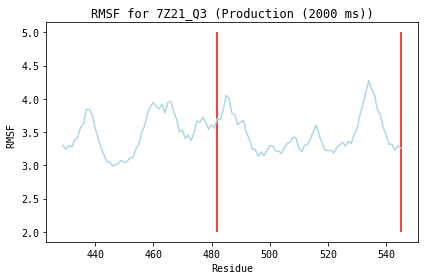

In [8]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_Q3"
file = "7Z21_Q3/rmsf_Q3.xvg"

calculation = "Production (2000 ms)"
value = "RMSF"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.vlines(482, 2, 5, color="red")
plt.vlines(545, 2, 5, color="red")
plt.plot(x[:546-429],y[:546-429], color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Residue")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

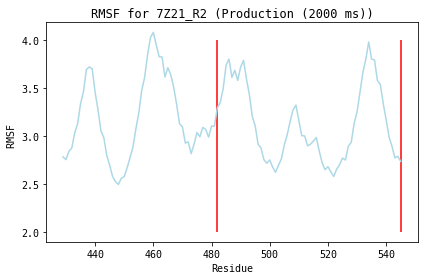

In [15]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_R2"
file = "7Z21_R2/rmsf_R2.xvg"

calculation = "Production (2000 ms)"
value = "RMSF"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.vlines(482, 2, 4, color="red")
plt.vlines(545, 2, 4, color="red")
plt.plot(x[:546-429],y[:546-429], color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Residue")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

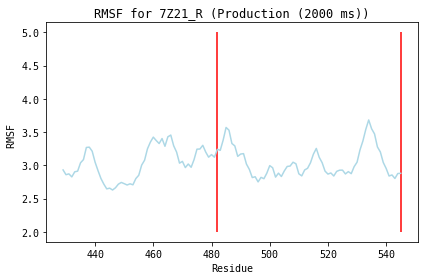

In [3]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_R"
file = "7Z21_R/rmsf_R.xvg"

calculation = "Production (2000 ms)"
value = "RMSF"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.vlines(482, 2, 5, color="red")
plt.vlines(545, 2, 5, color="red")
plt.plot(x[:546-429],y[:546-429], color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Residue")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()

In [ ]:
#!pip install gmxvg   # can be used but not necessary
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
import numpy as np

protein = "7Z21_Q3"
file = "7Z21_Q3/rmsf_Q3.xvg"

calculation = "Production (2000 ms)"
value = "RMSF"
unit = ""

title = f"{value} for {protein} ({calculation})" 
x,y = np.loadtxt(file,comments=("@", "#"),unpack=True)
plt.vlines(482, 2, 5, color="red")
plt.vlines(545, 2, 5, color="red")
plt.plot(x[:546-429],y[:546-429], color="lightblue", linestyle='-')
plt.title(title)
plt.xlabel("Residue")
plt.ylabel(f"{value} {unit}")
plt.tight_layout()
plt.savefig(file.replace("xvg", "png"))
plt.show()